In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from matplotlib import rcParams
import seaborn as sns
import os
from mpl_toolkits.mplot3d import Axes3D
from tqdm.auto import tqdm
from datasets import load_from_disk, load_dataset
from rich import print as pprint
import string
from collections import Counter
from scipy.stats import wasserstein_distance, ks_2samp, energy_distance
from scipy.spatial.distance import cosine
from scipy.spatial import distance

/home/takis/anaconda3/envs/unlearning/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:


rcParams['font.family'] = 'serif'
rcParams['text.usetex'] = False
rcParams['font.size'] = 25

rcParams['axes.grid'] = False
rcParams['grid.linestyle'] = '--'
rcParams['grid.alpha'] = 0.9

rcParams['axes.facecolor'] = 'white'
# rcParams['axes.facecolor'] = '#f8f9fa'
# rcParams['axes.linewidth'] = 2
# rcParams['axes.axisbelow'] = True
rcParams['axes.labelsize'] = 25
rcParams['axes.titlesize'] = 30

rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.bottom'] = True
rcParams['axes.spines.left'] = True

rcParams['lines.linewidth'] = 4
rcParams['lines.markersize'] = 15

rcParams['legend.fontsize'] = 25
rcParams['xtick.labelsize'] = 20
rcParams['ytick.labelsize'] = 20
rcParams['figure.figsize'] = (4, 6)



In [9]:
BoolQ_sample = [67.83, 67.00, 68.72, 67.58, 67.86, 62.69, 62.14, 62.17, 59.45, 62.17, 62.17, 62.17, 62.17]
BoolQ_seed = [70.06, 69.51, 68.87, 68.35, 68.84, 68.17, 68.87, 69.14, 71.38, 69.66]

np.mean(BoolQ_sample), np.std(BoolQ_sample), np.mean(BoolQ_seed), np.std(BoolQ_seed)

(np.float64(64.16307692307691),
 np.float64(2.986382902481977),
 np.float64(69.285),
 np.float64(0.8866707393390164))

In [11]:
BoolQ_sample = [67.77, 69.02, 69.11, 67.61, 66.15, 66.70, 62.72, 62.17, 62.60, 62.17, 62.17, 62.17, 62.17]
BoolQ_seed = [69.08, 68.62, 67.92, 67.98, 67.55, 67.95, 69.14, 68.29, 68.81, 62.39, ]

np.mean(BoolQ_sample), np.std(BoolQ_sample), np.mean(BoolQ_seed), np.std(BoolQ_seed)

(np.float64(64.80999999999999),
 np.float64(2.80499005894303),
 np.float64(67.773),
 np.float64(1.8643822033048914))

In [40]:
b = plt.boxplot(BoolQ_sample, widths=[0.4], positions=[0], vert=True, medianprops={'color': 'black'}, patch_artist=True)
for patch in b['boxes']:
    patch.set_facecolor('#a6a2a2')

b = plt.boxplot(BoolQ_seed, widths=[0.4], positions=[0.5], vert=True, medianprops={'color': 'black'}, flierprops={'color': 'black','mfc': '#2b9348'}, patch_artist=True)
for patch in b['boxes']:
    patch.set_facecolor('#2b9348')

plt.xticks([], [])
plt.xlim((-0.4, 0.8))
plt.title('BoolQ')
plt.ylabel('Accuracy')
plt.show()

NameError: name 'BoolQ_sample' is not defined

In [16]:
AG_sample = [85.28, 86.13, 84.30, 84.51, 84.41, 86.41, 83.25, 83.68, 80.38, 77.93, 80.99, 79.14, 81.54]
AG_seed = [85.37, 85.30, 86.58, 85.93, 85.84, 84.87, 84.68, 86.12, 86.08, 84.97]

np.mean(AG_sample), np.std(AG_sample), np.mean(AG_seed), np.std(AG_seed)

(np.float64(82.91923076923078),
 np.float64(2.581923735805298),
 np.float64(85.57400000000001),
 np.float64(0.5949823526794714))

In [17]:
AG_sample = [67.97, 67.57, 68.54, 69.53, 74.14, 60.76, 61.12, 62.11, 57.83, 30.37, 16.72, 26.08, 32.71, 49.70, 19.34]
AG_seed = [62.84,72.45,84.03,71.03,66.62,79.26,79.53,60.16, 72.62, 76.78]

np.mean(AG_sample), np.std(AG_sample), np.mean(AG_seed), np.std(AG_seed)

(np.float64(50.966000000000015),
 np.float64(19.454296800450024),
 np.float64(72.53200000000001),
 np.float64(7.271251336599499))

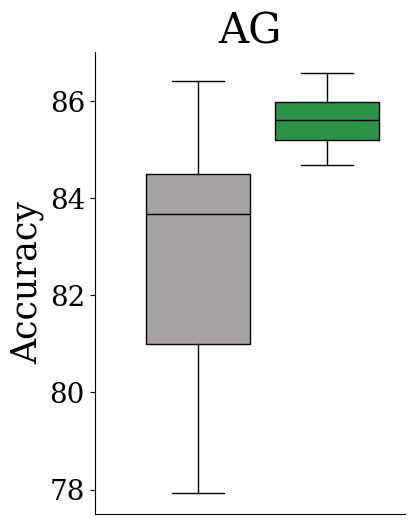

In [10]:
b = plt.boxplot(AG_sample, widths=[0.4], positions=[0], vert=True, medianprops={'color': 'black'}, patch_artist=True)
for patch in b['boxes']:
    patch.set_facecolor('#a6a2a2')

b = plt.boxplot(AG_seed, widths=[0.4], positions=[0.5], vert=True, medianprops={'color': 'black'}, flierprops={'color': 'black','mfc': '#2b9348'}, patch_artist=True)
for patch in b['boxes']:
    patch.set_facecolor('#2b9348')

plt.xticks([], [])
plt.xlim((-0.4, 0.8))
# plt.ylim((0, 90))
plt.title('AG')
plt.ylabel('Accuracy')
plt.show()

# Manifold

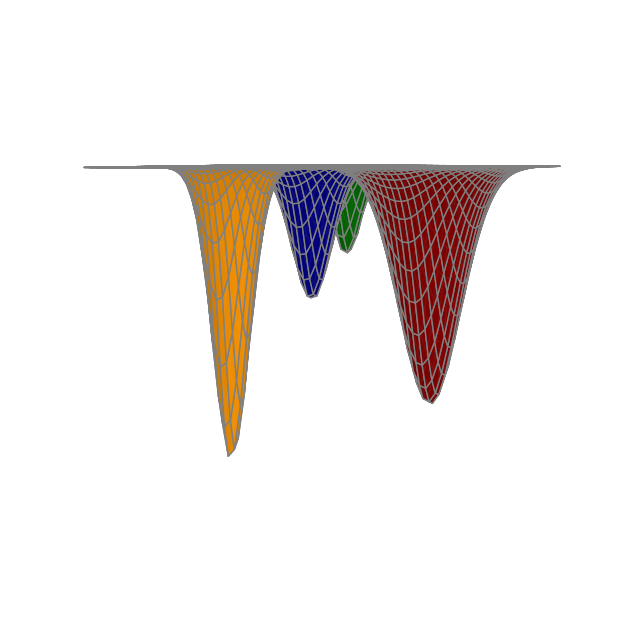

In [3]:







# Create grid
x = np.linspace(-6, 6, 50)
y = np.linspace(-6, 6, 50)
X, Y = np.meshgrid(x, y)

base = 0.2 * np.ones_like(X)
dips = (-0.5 * np.exp(-((X - 2)**2 + (Y - 2)**2) / 0.5),
        -0.8 * np.exp(-((X + 1.5)**2 + (Y + 1.5)**2) / 1.0),
        -1.7 * np.exp(-((X - 3)**2 + (Y + 2)**2) / 0.8),
        -1.4 * np.exp(-((X + 2)**2 + (Y - 3)**2) / 2.3))

# Plot in 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=3, azim=31)




ax.plot_surface(X, Y, base + dips[0], color='#006F00', edgecolor='gray', alpha=0.9)
ax.plot_surface(X, Y, base + dips[1], color='#00008B', edgecolor='gray', alpha=0.9)
ax.plot_surface(X, Y, base + dips[2], color='#FF9700', edgecolor='gray', alpha=0.9)
ax.plot_surface(X, Y, base + dips[3], color='#8B0000', edgecolor='gray', alpha=0.9)

# ax.plot_surface(X, Y, base, color='gray', edgecolor='gray')

# surf = ax.plot_surface(X, Y, Z, cmap='gray', edgecolor='gray')

# Hide background and all visual elements
ax.set_axis_off()
ax.grid(False)

# Optional: explicitly hide panes and ticks
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

# ax.set_title("3D Surface Plot with Local Minima")
# ax.set_xlabel("x")
# ax.set_ylabel("y")
# ax.set_zlabel("z")
# fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

plt.savefig("contour.png", transparent=True, bbox_inches='tight', pad_inches=0)

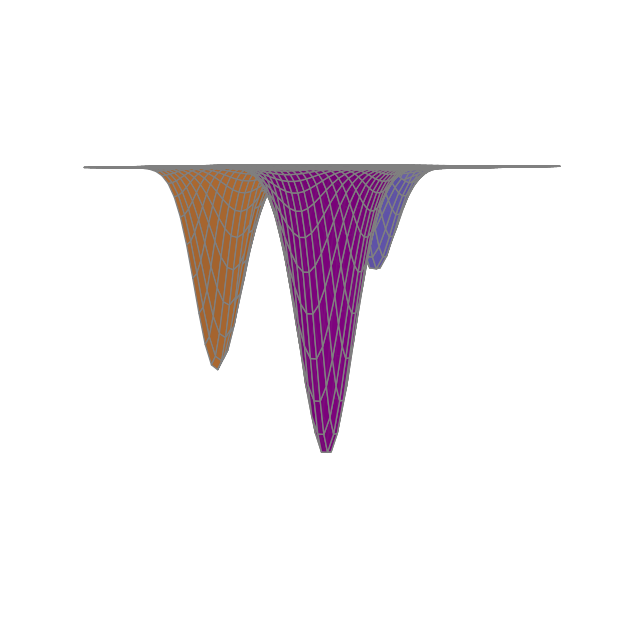

In [7]:

# Create grid
x = np.linspace(-6, 3, 50)
y = np.linspace(-6, 3, 50)
X, Y = np.meshgrid(x, y)

base = 0.2 * np.ones_like(X)
dips = (-0.1 * np.exp(-((X - 2)**2 + (Y - 2)**2) / 0.5),
        -0.3 * np.exp(-((X + 1.5)**2 + (Y + 1.5)**2) / 1.0),
        -0.2 * np.exp(-((X - 3)**2 + (Y + 2)**2) / 0.8))

# Plot in 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=3, azim=31)




ax.plot_surface(X, Y, base + dips[0], color='#7565D3', edgecolor='gray', alpha=0.9)
ax.plot_surface(X, Y, base + dips[1], color='#960096', edgecolor='gray', alpha=0.9)
ax.plot_surface(X, Y, base + dips[2], color='#D87421', edgecolor='gray', alpha=0.9)

# ax.plot_surface(X, Y, base, color='gray', edgecolor='gray')

# surf = ax.plot_surface(X, Y, Z, cmap='gray', edgecolor='gray')

# Hide background and all visual elements
ax.set_axis_off()
ax.grid(False)

# Optional: explicitly hide panes and ticks
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

# ax.set_title("3D Surface Plot with Local Minima")
# ax.set_xlabel("x")
# ax.set_ylabel("y")
# ax.set_zlabel("z")
# fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

plt.savefig("contour2.png", transparent=True, bbox_inches='tight', pad_inches=0)

# Biographies

In [15]:
temp_ratio = [0.6294117647058823,
 0.5466666666666666,
 0.6770833333333334,
 0.6037735849056604,
 0.5432098765432098,
 0.5984848484848485,
 0.6780487804878049,
 0.5528846153846154,
 0.6139240506329114,
 0.6917808219178082,
 0.743421052631579,
 0.6571428571428571,
 0.5967741935483871,
 0.6339869281045751,
 0.7247191011235955,
 0.5833333333333334,
 0.8218390804597702,
 0.768361581920904,
 0.5825688073394495,
 0.6714285714285714,
 0.6452991452991453,
 0.6405228758169934,
 0.6275862068965518,
 0.6172839506172839,
 0.6345177664974619,
 0.6,
 0.6962962962962963,
 0.601063829787234,
 0.5639097744360902,
 0.7011494252873564,
 0.5888888888888889,
 0.6818181818181818,
 0.6241610738255033]


latent_ratio = [0.6684491978609626,
 0.6880733944954128,
 0.770949720670391,
 0.8389261744966443,
 0.8641114982578397,
 0.8181818181818182,
 0.8085106382978723,
 0.8323699421965318,
 0.6691176470588235,
 0.7547169811320755,
 0.7790697674418605,
 0.8244274809160306,
 0.6458333333333334,
 0.8536585365853658,
 0.8581560283687943,
 0.7605633802816901,
 0.8223684210526315,
 0.8117647058823529,
 0.8181818181818182,
 0.819672131147541,
 0.92,
 0.8571428571428571,
 0.7142857142857143,
 0.864516129032258,
 0.7910447761194029,
 0.777027027027027,
 0.8454545454545455,
 0.6549707602339181,
 0.7521367521367521,
 0.8931297709923665,
 0.7248322147651006,
 0.8543046357615894,
 0.7284768211920529]


names = ['Nelson Mandela',
 'Angela Merkel',
 'Mahatma Gandhi',
 'Winston Churchill',
 'Barack Obama',
 'Margaret Thatcher',
 'Justin Trudeau',
 'Jacinda Ardern',
 'Emmanuel Macron',
 'Xi Jinping',
 'Albert Einstein',
 'Isaac Newton',
 'Marie Curie',
 'Nikola Tesla',
 'Ada Lovelace',
 'Rosalind Franklin',
 'Stephen Hawking',
 'Katherine Johnson',
 'Tim Berners-Lee',
 'Elon Musk',
 'William Shakespeare',
 'Leo Tolstoy',
 'Gabriel García Márquez',
 'Virginia Woolf',
 'Chinua Achebe',
 'Haruki Murakami',
 'J.K. Rowling',
 'George Orwell',
 'Jean-Paul Sartre',
 'Rumi',
 'Pablo Picasso',
 'Frida Kahlo',
 'Vincent van Gogh']

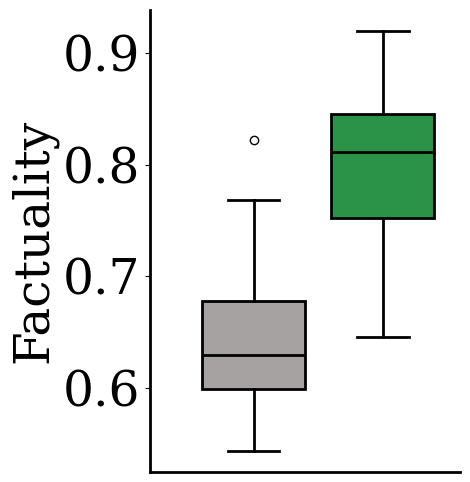

In [29]:

rcParams['font.family'] = 'serif'
rcParams['text.usetex'] = False
rcParams['font.size'] = 25




rcParams['axes.grid'] = False
rcParams['grid.linestyle'] = '--'
rcParams['grid.alpha'] = 0.9


rcParams['axes.linewidth'] = 2
rcParams['axes.facecolor'] = 'white'
# rcParams['axes.facecolor'] = '#f8f9fa'
# rcParams['axes.axisbelow'] = True
rcParams['axes.labelsize'] = 35
rcParams['axes.titlesize'] = 30

rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.bottom'] = True
rcParams['axes.spines.left'] = True

rcParams['lines.linewidth'] = 4
rcParams['lines.markersize'] = 15

rcParams['legend.fontsize'] = 35
rcParams['xtick.labelsize'] = 35
rcParams['ytick.labelsize'] = 35
rcParams['figure.figsize'] = (4, 6)










b = plt.boxplot(temp_ratio, widths=[0.4], positions=[0], vert=True, 
                medianprops={'color': 'black', 'linewidth': 2}, 
                boxprops={'linewidth': 2}, 
                whiskerprops={'linewidth': 2},
                capprops={'linewidth': 2},
                flierprops={'linewidth': 2}, 
                patch_artist=True)

for patch in b['boxes']:
    patch.set_facecolor('#a6a2a2')

b = plt.boxplot(latent_ratio, widths=[0.4], positions=[0.5], vert=True, 
                medianprops={'color': 'black', 'linewidth': 2}, 
                boxprops={'linewidth': 2}, 
                whiskerprops={'linewidth': 2},
                capprops={'linewidth': 2},
                flierprops={'color': 'black','mfc': '#2b9348', 'linewidth': 2}, 
                patch_artist=True)
for patch in b['boxes']:
    patch.set_facecolor('#2b9348')

plt.xticks([], [])
plt.xlim((-0.4, 0.8))
plt.yticks([0.6, 0.7, 0.8, 0.9])
# plt.title('BoolQ')
plt.ylabel('Factuality')
plt.show()

In [5]:
all_info = []

for i in range(len(names)):
    all_info.append((names[i], temp_ratio[i], latent_ratio[i]))


all_info = sorted(all_info, key=lambda x: -x[2])

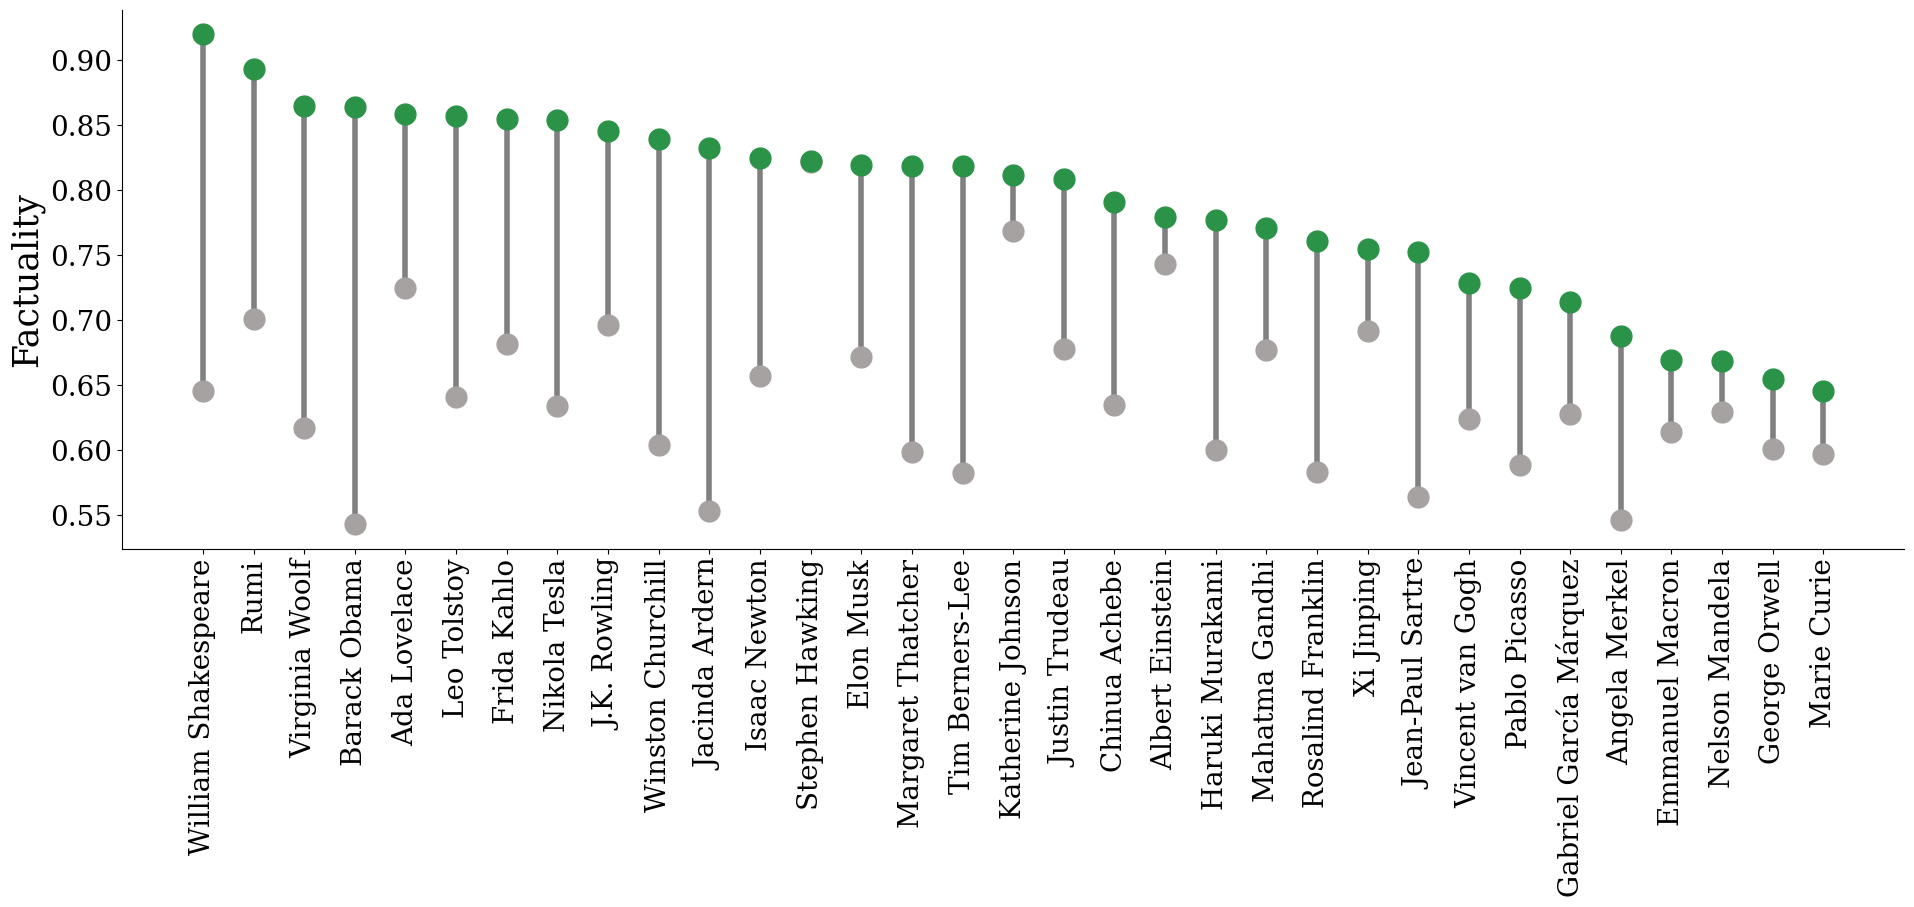

In [11]:

rcParams['figure.figsize'] = (23, 7)


for i in range(len(all_info)):
    plt.plot([i, i], [all_info[i][1], all_info[i][2]], '-', c='gray')

plt.plot(list(range(len(all_info))), [el[1] for el in all_info], 'o', c='#a6a2a2')
plt.plot(list(range(len(all_info))), [el[2] for el in all_info], 'o', c='#2b9348')

plt.xticks(list(range(len(all_info))), [el[0] for el in all_info], rotation=90)


plt.ylabel('Factuality')


plt.show()



# Dataset statistics

## BoolQ

In [4]:


datasets_path = '/data/takis/SynthGen/datasets/BoolQ_100'

original_d = load_dataset("google/boolq", cache_dir='/data/takis/datasets/hf_hub')['validation']

original_prompts = []
for d in original_d:
    prompt = ''
    for k in d.keys():
        prompt = prompt + str(d[k]).lower().translate(str.maketrans('', '', string.punctuation)) + ' '
    original_prompts.append(prompt)

original_lengths = [len(p) for p in original_prompts]
original_counter = Counter((' '.join(original_prompts)).split(' '))



#################################################################### <Temp> ####################################################################
temp_divs = []
temp_wass = []
temp_vocab = []
temp_samples = []

# for temp in ['0.200', '0.400', '0.600', '0.800', '1.000', '1.200', '1.400', '1.600', '1.800', '2.000', '2.200', '2.400', '2.600', '2.800', '3.000']:
for temp in ['1.000', '1.200', '1.400', '1.600', '1.800', '2.000', '2.200', '2.400', '2.600']:

    name = 'topK_50_topP_0.990_temp_%s_reps_10.hf' %(temp)
    
    try:
        generated_d = load_from_disk(os.path.join(datasets_path, 'sample', name))
    except:
        continue


    generated_w = []
    generated_prompts = []

    for d in tqdm(generated_d, total=len(generated_d)):
        prompt = d['passage'] + ' ' + d['question']    
        w = prompt.lower().translate(str.maketrans('', '', string.punctuation)).split(' ')
            
        generated_w.extend(w)
        generated_prompts.append(prompt)

    generated_lengths = [len(p) for p in generated_prompts]
    generated_counter = Counter((' '.join(generated_prompts)).split(' '))

    temp_vocab.append(len(set(generated_w)))
    temp_samples.append(len(set(generated_prompts)))


    all_keys = set(original_counter) | set(generated_counter)

    vec1 = np.array([original_counter.get(k, 0) for k in all_keys])
    vec2 = np.array([generated_counter.get(k, 0) for k in all_keys])

    # Normalize to probability distributions
    prob1 = vec1 / vec1.sum()
    prob2 = vec2 / vec2.sum()

    # Cosine similarity (1 = identical, 0 = orthogonal)
    cos_sim = 1 - cosine(prob1, prob2)

    # Jensen-Shannon divergence (lower = more similar)
    temp_divs.append(jsd := distance.jensenshannon(prob1, prob2).item())

    # KS test
    ks_stat, ks_pval = ks_2samp(original_lengths, generated_lengths)

    # Wasserstein distance
    temp_wass.append(wdist := wasserstein_distance(original_lengths, generated_lengths).item())

    # Energy distance
    edist = energy_distance(original_lengths, generated_lengths)
#################################################################### </Temp> ####################################################################


#################################################################### <Latent> ####################################################################
lat_divs = []
lat_wass = []
lat_vocab = []
lat_samples = []

for denom in ['5.00', '10.00', '15.00', '20.00', '25.00', '30.00', '35.00', '40.00', '45.00', '50.00']:

    name = 'topK_50_topP_0.990_temp_0.400_layer_16_denom_%s_reps_10.hf' %(denom)
    
    try:
        generated_d = load_from_disk(os.path.join(datasets_path, 'sample_seed', name))
    except:
        continue

    generated_w = []
    generated_prompts = []

    for d in tqdm(generated_d, total=len(generated_d)):
        prompt = d['passage'] + ' ' + d['question']    
        w = prompt.lower().translate(str.maketrans('', '', string.punctuation)).split(' ')
            
        generated_w.extend(w)
        generated_prompts.append(prompt)

    generated_lengths = [len(p) for p in generated_prompts]
    generated_counter = Counter((' '.join(generated_prompts)).split(' '))


    lat_vocab.append(len(set(generated_w)))
    lat_samples.append(len(set(generated_prompts)))


    all_keys = set(original_counter) | set(generated_counter)

    vec1 = np.array([original_counter.get(k, 0) for k in all_keys])
    vec2 = np.array([generated_counter.get(k, 0) for k in all_keys])

    # Normalize to probability distributions
    prob1 = vec1 / vec1.sum()
    prob2 = vec2 / vec2.sum()

    # Cosine similarity (1 = identical, 0 = orthogonal)
    cos_sim = 1 - cosine(prob1, prob2)

    # Jensen-Shannon divergence (lower = more similar)
    lat_divs.append(jsd := distance.jensenshannon(prob1, prob2).item())

    # KS test
    ks_stat, ks_pval = ks_2samp(original_lengths, generated_lengths)

    # Wasserstein distance
    lat_wass.append(wdist := wasserstein_distance(original_lengths, generated_lengths).item())

    # Energy distance
    edist = energy_distance(original_lengths, generated_lengths)
#################################################################### </Latent> ####################################################################



# box = plt.boxplot(sample_lengths, widths=[0.4], positions=[0], vert=True, medianprops={'color': 'black'}, patch_artist=True)
# for patch in box['boxes']:
#     patch.set_facecolor('#a6a2a2')

# box = plt.boxplot(seed_lengths, widths=[0.4], positions=[0.5], vert=True, medianprops={'color': 'black'}, flierprops={'color': 'black','mfc': '#2b9348'}, patch_artist=True)
# for patch in box['boxes']:
#     patch.set_facecolor('#2b9348')

# box = plt.boxplot(original_lengths, widths=[0.4], positions=[1], vert=True, medianprops={'color': 'black'}, flierprops={'color': 'black','mfc': 'blue'}, patch_artist=True)
# for patch in box['boxes']:
#     patch.set_facecolor('blue')

# plt.xticks([], [])
# # plt.xlim((-0.4, 0.8))
# plt.title(b)
# plt.ylabel('Length')
# plt.show()





100%|██████████| 2684/2684 [00:00<00:00, 39311.21it/s]


In [5]:
pprint ('--------------------------------------------------')
pprint ('Divergence')
pprint (temp_divs, np.mean(temp_divs), np.std(temp_divs))
pprint (lat_divs, np.mean(lat_divs), np.std(lat_divs))
pprint ('--------------------------------------------------')
pprint ('Wasserstein')
pprint (temp_wass, np.mean(temp_wass), np.std(temp_wass))
pprint (lat_wass, np.mean(lat_wass), np.std(lat_wass))
pprint ('--------------------------------------------------')
pprint ('Vocabulary')
pprint (temp_vocab, np.mean(temp_vocab), np.std(temp_vocab))
pprint (lat_vocab, np.mean(lat_vocab), np.std(lat_vocab))
pprint ('--------------------------------------------------')
pprint ('Samples')
pprint (temp_samples, np.mean(temp_samples), np.std(temp_samples))
pprint (lat_samples, np.mean(lat_samples), np.std(lat_samples))
pprint ('--------------------------------------------------')

--------------------------------------------------

Divergence

[
    0.4290954968960475,
    0.4183103972308802,
    0.41960452847811613,
    0.4325727468226923,
    0.44613616599367373,
    0.45986348452721,
    0.46544696312829287,
    0.4763093705148904,
    0.4781735757805445
]
0.447279192152483 0.022208500417705612

[
    0.46977276835722,
    0.4635018899801675,
    0.4651244299289115,
    0.46494973920954036,
    0.46280702180653954,
    0.4639780261745541,
    0.4644524826491822,
    0.4658669926985698,
    0.4658096537003303,
    0.4629143176256586
]
0.4649177322130674 0.0019205370607360832

--------------------------------------------------

...

--------------------------------------------------

Samples

[2953, 2500, 1748, 1190, 875, 695, 676, 586, 547]
1307.7777777777778 843.1092953767129

[2726, 2748, 2723, 2684, 2669, 2649, 2542, 2572, 2789, 2645]
2674.7 72.95210757750594

--------------------------------------------------

# AG

In [6]:

datasets_path = '/data/takis/SynthGen/datasets/AG_100'

original_d = load_dataset("google/boolq", cache_dir='/data/takis/datasets/hf_hub')['validation']

original_prompts = []
for d in original_d:
    prompt = ''
    for k in d.keys():
        prompt = prompt + str(d[k]).lower().translate(str.maketrans('', '', string.punctuation)) + ' '
    original_prompts.append(prompt)

original_lengths = [len(p) for p in original_prompts]
original_counter = Counter((' '.join(original_prompts)).split(' '))



#################################################################### <Temp> ####################################################################
temp_divs = []
temp_wass = []
temp_vocab = []
temp_samples = []

# for temp in ['0.200', '0.400', '0.600', '0.800', '1.000', '1.200', '1.400', '1.600', '1.800', '2.000', '2.200', '2.400', '2.600', '2.800', '3.000']:
for temp in ['1.000', '1.200', '1.400', '1.600', '1.800', '2.000', '2.200', '2.400', '2.600']:

    name = 'topK_50_topP_0.990_temp_%s_reps_10.hf' %(temp)
    
    try:
        generated_d = load_from_disk(os.path.join(datasets_path, 'sample', name))
    except:
        continue


    generated_w = []
    generated_prompts = []

    for d in tqdm(generated_d, total=len(generated_d)):
        prompt = d['text']  
        w = prompt.lower().translate(str.maketrans('', '', string.punctuation)).split(' ')
            
        generated_w.extend(w)
        generated_prompts.append(prompt)

    generated_lengths = [len(p) for p in generated_prompts]
    generated_counter = Counter((' '.join(generated_prompts)).split(' '))

    temp_vocab.append(len(set(generated_w)))
    temp_samples.append(len(set(generated_prompts)))


    all_keys = set(original_counter) | set(generated_counter)

    vec1 = np.array([original_counter.get(k, 0) for k in all_keys])
    vec2 = np.array([generated_counter.get(k, 0) for k in all_keys])

    # Normalize to probability distributions
    prob1 = vec1 / vec1.sum()
    prob2 = vec2 / vec2.sum()

    # Cosine similarity (1 = identical, 0 = orthogonal)
    cos_sim = 1 - cosine(prob1, prob2)

    # Jensen-Shannon divergence (lower = more similar)
    temp_divs.append(jsd := distance.jensenshannon(prob1, prob2).item())

    # KS test
    ks_stat, ks_pval = ks_2samp(original_lengths, generated_lengths)

    # Wasserstein distance
    temp_wass.append(wdist := wasserstein_distance(original_lengths, generated_lengths).item())

    # Energy distance
    edist = energy_distance(original_lengths, generated_lengths)
#################################################################### </Temp> ####################################################################


#################################################################### <Latent> ####################################################################
lat_divs = []
lat_wass = []
lat_vocab = []
lat_samples = []

for denom in ['5.00', '10.00', '15.00', '20.00', '25.00', '30.00', '35.00', '40.00', '45.00', '50.00']:

    name = 'topK_50_topP_0.990_temp_0.400_layer_16_denom_%s_reps_10.hf' %(denom)
    
    try:
        generated_d = load_from_disk(os.path.join(datasets_path, 'sample_seed', name))
    except:
        continue

    generated_w = []
    generated_prompts = []

    for d in tqdm(generated_d, total=len(generated_d)):
        prompt = d['text']    
        w = prompt.lower().translate(str.maketrans('', '', string.punctuation)).split(' ')
            
        generated_w.extend(w)
        generated_prompts.append(prompt)

    generated_lengths = [len(p) for p in generated_prompts]
    generated_counter = Counter((' '.join(generated_prompts)).split(' '))


    lat_vocab.append(len(set(generated_w)))
    lat_samples.append(len(set(generated_prompts)))


    all_keys = set(original_counter) | set(generated_counter)

    vec1 = np.array([original_counter.get(k, 0) for k in all_keys])
    vec2 = np.array([generated_counter.get(k, 0) for k in all_keys])

    # Normalize to probability distributions
    prob1 = vec1 / vec1.sum()
    prob2 = vec2 / vec2.sum()

    # Cosine similarity (1 = identical, 0 = orthogonal)
    cos_sim = 1 - cosine(prob1, prob2)

    # Jensen-Shannon divergence (lower = more similar)
    lat_divs.append(jsd := distance.jensenshannon(prob1, prob2).item())

    # KS test
    ks_stat, ks_pval = ks_2samp(original_lengths, generated_lengths)

    # Wasserstein distance
    lat_wass.append(wdist := wasserstein_distance(original_lengths, generated_lengths).item())

    # Energy distance
    edist = energy_distance(original_lengths, generated_lengths)
#################################################################### </Latent> ####################################################################

100%|██████████| 9255/9255 [00:00<00:00, 77420.10it/s]


In [7]:
pprint ('--------------------------------------------------')
pprint ('Divergence')
pprint (temp_divs, np.mean(temp_divs), np.std(temp_divs))
pprint (lat_divs, np.mean(lat_divs), np.std(lat_divs))
pprint ('--------------------------------------------------')
pprint ('Wasserstein')
pprint (temp_wass, np.mean(temp_wass), np.std(temp_wass))
pprint (lat_wass, np.mean(lat_wass), np.std(lat_wass))
pprint ('--------------------------------------------------')
pprint ('Vocabulary')
pprint (temp_vocab, np.mean(temp_vocab), np.std(temp_vocab))
pprint (lat_vocab, np.mean(lat_vocab), np.std(lat_vocab))
pprint ('--------------------------------------------------')
pprint ('Samples')
pprint (temp_samples, np.mean(temp_samples), np.std(temp_samples))
pprint (lat_samples, np.mean(lat_samples), np.std(lat_samples))
pprint ('--------------------------------------------------')

--------------------------------------------------

Divergence

[
    0.515720294581195,
    0.5067412862825843,
    0.5019231070760487,
    0.5029632502308362,
    0.5116798815562841,
    0.5114576405067061,
    0.5199792696025307,
    0.5199551345250418,
    0.5200705708514471
]
0.5122767150236305 0.006802742833206858

[
    0.5350174810388821,
    0.5365188079589122,
    0.5377424363154782,
    0.5395466505683334,
    0.539131446795575,
    0.5380788880308174,
    0.5388360536333353,
    0.5383691698905033,
    0.5390284364371235,
    0.5392970322321915
]
0.5381566402901152 0.0013477424018811534

--------------------------------------------------

...

--------------------------------------------------

Samples

[6560, 5135, 3788, 3064, 2223, 2064, 1711, 1644, 1472]
3073.4444444444443 1670.767761713233

[7144, 8797, 8929, 8878, 8562, 8600, 8673, 8785, 8993, 8410]
8577.1 507.0081754764907

--------------------------------------------------